In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\douga\AppData\Local\Temp\ipykernel_18012\2039331549.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Frequency [$\mu$Hz]")


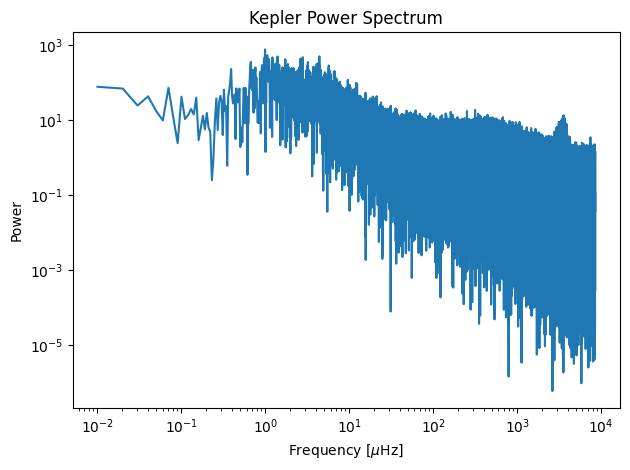

In [5]:
# Path to the .pow file
pow_file1 = r"C:\Users\douga\Documents\Asteroseismology\GroupStudies202021_KeplerSpectra_Batch1\GroupStudies202021_KeplerSpectra\kplr008006161_kasoc-ts_slc_v1.pow"
pow_file2 = r"C:\Users\douga\Documents\Asteroseismology\GroupStudies202021_KeplerSpectra_Batch1\GroupStudies202021_KeplerSpectra\kplr008174981_kasoc-ts_slc_v1.pow"
pow_file3 = r"C:\Users\douga\Documents\Asteroseismology\GroupStudies202021_KeplerSpectra_Batch1\GroupStudies202021_KeplerSpectra\kplr012009504_kasoc-ts_slc_v1.pow"
# Load the data
# Assumes: column 0 = frequency (µHz), column 1 = power
data = np.loadtxt(pow_file1)

freq = data[:, 0]
power = data[:, 1]

# Plot
plt.figure()
plt.plot(freq, power)
plt.xlabel("Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.title("Kepler Power Spectrum")
plt.yscale("log")  # standard for asteroseismic power spectra
plt.xscale("log")
#plt.xlim(3000,4000)
plt.tight_layout()
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
C:\Users\douga\AppData\Local\Temp\ipykernel_18012\2541372181.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Frequency [$\mu$Hz]")


Median Δν bin: 0.01008606684604274
Std of Δν bin: 3.4036241505959237e-13
Min power: 5.829992566305415e-07
Any NaNs? False
Any infs? False
Δf = 0.01008606684604274 µHz
Smoothing width (bins): 991


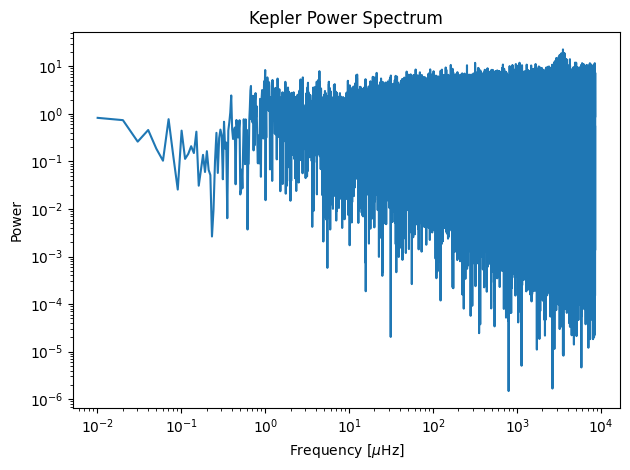

In [9]:
df = np.diff(freq)

print("Median Δν bin:", np.median(df))
print("Std of Δν bin:", np.std(df))

print("Min power:", np.min(power))
print("Any NaNs?", np.any(np.isnan(power)))
print("Any infs?", np.any(np.isinf(power)))
df = np.median(np.diff(freq))  # µHz
print("Δf =", df, "µHz")

smooth_width_muHz = 10
smooth_width_bins = int(smooth_width_muHz / df)
print("Smoothing width (bins):", smooth_width_bins)
background = uniform_filter1d(power, size =smooth_width_bins)

power_flat = power / background
#power_flat /= np.median(power_flat)

plt.figure()
plt.plot(freq, power_flat)
plt.xlabel("Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.title("Kepler Power Spectrum")
plt.yscale("log")  # standard for asteroseismic power spectra
plt.xscale("log")
plt.tight_layout()
plt.show()

In [11]:
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772

def sliding_acf_search(frequency, power_flat, numax_grid,
                       k_width=4.0,
                       lag_frac=(0.8, 1.2)):
    """
    Sliding ACF p-mode search.

    freq, power : full spectrum
    numax_grid  : trial νmax values (μHz)
    k_width     : window width in units of Δν
    lag_frac    : fraction of Δν to search for ACF peak
    """

    acf_strength = []

    for nu_c in tqdm(numax_grid):

        # Δν estimate
        dnu = delta_nu_from_numax(nu_c)

        # Window size
        W = k_width * dnu

        mask = (freq > nu_c - W/2) & (freq < nu_c + W/2)
        if mask.sum() < 20:
            acf_strength.append(0.0)
            continue

        # Local, whitened spectrum
        p = power_flat[mask]
        p = p / np.median(p)

        # Autocorrelation
        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size//2:]

        # Lag axis
        df = freq[1] - freq[0]
        lag = np.arange(acf.size) * df

        # Measure strength near Δν
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)
        strength = np.max(acf[lag_mask])

        acf_strength.append(strength)

    return np.array(acf_strength)


In [ ]:
numax_grid = np.linspace(50, 5000, 100)

acf_power = sliding_acf_search(
    freq,
    power_flat,
    numax_grid,
    k_width=4.0
)

numax_est = numax_grid[np.argmax(acf_power)]


 57%|█████▋    | 57/100 [05:58<09:13, 12.87s/it]

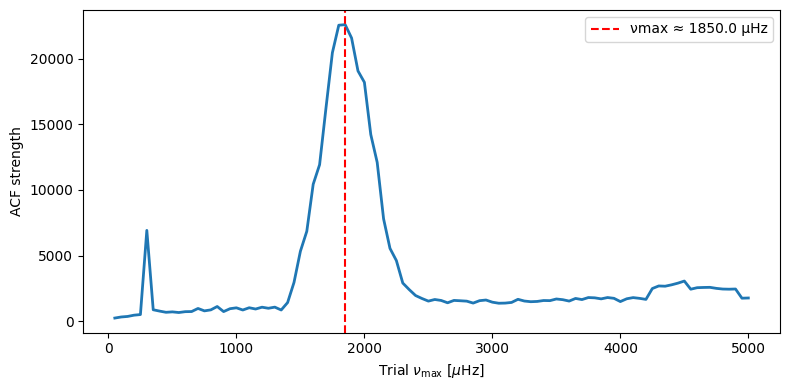

In [188]:
plt.figure(figsize=(8,4))
plt.plot(numax_grid, acf_power, lw=2)
plt.axvline(numax_est, color="r", ls="--", label=f"νmax ≈ {numax_est:.1f} μHz")
plt.xlabel(r"Trial $\nu_{\max}$ [$\mu$Hz]")
plt.ylabel("ACF strength")
plt.legend()
plt.tight_layout()
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\douga\AppData\Local\Temp\ipykernel_21444\676552636.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Frequency [$\mu$Hz]")


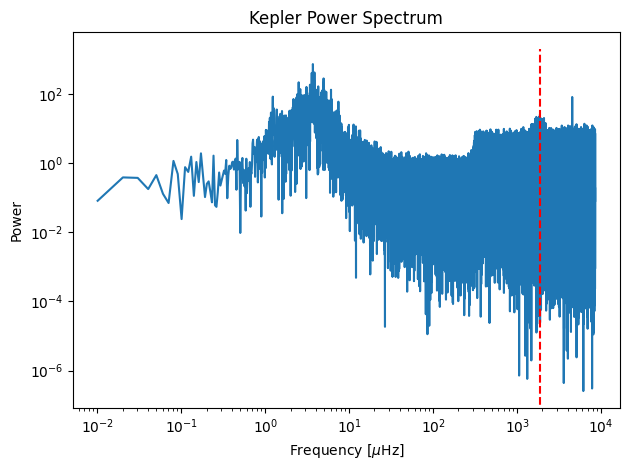

In [189]:
plt.figure()
plt.plot(freq, power_flat)
plt.xlabel("Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.vlines(numax_est, 0, 2000, color = "r", linestyle ="dashed")
plt.title("Kepler Power Spectrum")
plt.yscale("log")  # standard for asteroseismic power spectra
plt.xscale("log")
plt.tight_layout()
plt.show()

In [1]:
delta_nu_est = delta_nu_from_numax(numax_est)
width = 4* delta_nu_est
mask = (freq >= numax_est - width/2) & (freq <= numax_est + width/2)
freq_window = freq[mask]
power_window = power[mask]

acf_full = np.correlate(power_window, power_window, mode="full")
N = len(power_window)
acf = acf_full[N-1:]
lags_bins = np.arange(len(acf))
lags_muHz = lags_bins * df
acf /= acf[0]
lag_min = 20.0
lag_max = 200.0

mask_lag = (lags_muHz >= lag_min) & (lags_muHz <= lag_max)

lags_plot = lags_muHz[mask_lag]
acf_plot = acf[mask_lag]

plt.figure()
plt.plot(lags_plot, acf_plot, lw=1)
plt.axhline(0.0, color="k", ls="--", lw=0.8)
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalised ACF")
plt.title("Autocorrelation of flattened power spectrum")
plt.tight_layout()
plt.show()


NameError: name 'delta_nu_from_numax' is not defined